# EfficientNet-B0 for ECG Arrhythmia Detection

## 1. Problem Definition

### Clinical Relevance
Cardiovascular diseases are the leading cause of death globally. Early detection of arrhythmias (irregular heartbeats) from Electrocardiograms (ECG) is critical for preventing strokes and sudden cardiac death. Manual interpretation of long-term ECG recordings (Holter monitors) is time-consuming and error-prone.

### Prediction Goal
The goal is to classify individual heartbeats from a single-lead ECG signal into one of four clinically relevant categories based on the AAMI standard:
- **N**: Normal beat
- **S**: Supraventricular premature beat
- **V**: Premature ventricular contraction
- **F**: Fusion of ventricular and normal beat

*(Note: The 'Q' class (Unclassifiable) is excluded from this analysis as per standard practice).* 


In [ ]:
!pip install wfdb librosa tqdm opencv-python

In [23]:
import random
import numpy as np
import torch
import os
import h5py
import wfdb
import librosa
from scipy.signal import butter, filtfilt, iirnotch
import cv2
from tqdm.notebook import tqdm
from pathlib import Path
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools
import ssl

# Fix SSL for Model Download
ssl._create_default_https_context = ssl._create_unverified_context

# Device Logic
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
if not torch.backends.mps.is_available() and torch.cuda.is_available():
    DEVICE = torch.device('cuda')
print(f"Using Device: {DEVICE}")


Using Device: mps


## 2. Dataset Documentation

### Citation
> Moody GB, Mark RG. The impact of the MIT-BIH Arrhythmia Database. IEEE Eng in Med and Biol 20(3):45-50 (May-June 2001). (PMID: 11446209)

### Variables & Description
- **Source**: MIT-BIH Arrhythmia Database (via PhysioNet).
- **Input**: Single-channel ECG signals (Lead II), sampled at 360 Hz.
- **Labels**: Annotated beat types (N, S, V, F).

### Preprocessing Steps
1.  **Denoising**: 
    - Notch Filter (60Hz) to remove powerline interference.
    - Bandpass Filter (0.5Hz - 40Hz) to remove baseline wander and high-frequency muscle noise.
2.  **Segmentation**: Beats extracted using a fixed window around the R-peak (-431ms to +433ms).
3.  **Spectrogram Conversion**: 
    - Short-Time Fourier Transform (STFT).
    - Amplitude to Decibel (dB) conversion.
    - Resizing to **224x224** pixels (compatible with EfficientNet).
    - Min-Max Normalization to [0, 1].


In [24]:
# Configuration
DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'mit-bih-arrhythmia-database-1.0.0'
HDF5_FILE = DATA_DIR / 'mit_bih_spectrograms_ultimate.h5'

# --- Filtering & Processing Functions ---

def download_mitdb():
    if not RAW_DIR.exists():
        print(f"Downloading MIT-BIH Arrhythmia Database...")
        os.makedirs(RAW_DIR, exist_ok=True)
        wfdb.dl_database('mitdb', str(RAW_DIR))
    else:
        print("Database already exists.")

def apply_filters(data, fs=360):
    # Notch Filter (60Hz)
    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    data = filtfilt(b_notch, a_notch, data)
    # Bandpass (0.5 - 40Hz)
    b_high, a_high = butter(2, 0.5 / (0.5 * fs), btype='high')
    data = filtfilt(b_high, a_high, data)
    b_low, a_low = butter(2, 40.0 / (0.5 * fs), btype='low')
    data = filtfilt(b_low, a_low, data)
    return data

def normalize(arr):
    ptp = np.ptp(arr)
    if ptp == 0: return arr
    return (arr - np.min(arr)) / ptp

def compute_spectrogram(signal, fs=360, n_fft=512, hop_length=2):
    stft = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
    spectrogram = np.abs(stft)
    log_spectrogram = librosa.amplitude_to_db(spectrogram, ref=np.max)
    # Resize for EfficientNet (224x224)
    resized_img = cv2.resize(log_spectrogram, (224, 224), interpolation=cv2.INTER_LINEAR)
    return normalize(resized_img)

def translate_beat_type(beat_type_arr, peak_loc_arr):
    # Mapping standard MIT-BIH codes to AAMI classes
    n_type = ['N', 'L', 'R', 'e', 'j']
    s_type = ['A', 'a', 'J', 'S']
    v_type = ['V', 'E']
    f_type = ['F']
    encoded_label, peak_loc_label = [], []
    for beat, peak in zip(beat_type_arr, peak_loc_arr):
        if beat in n_type: encoded_label.append(0)
        elif beat in s_type: encoded_label.append(1)
        elif beat in v_type: encoded_label.append(2)
        elif beat in f_type: encoded_label.append(3)
        else: continue
        peak_loc_label.append(peak)
    return np.array(encoded_label), np.array(peak_loc_label)

# --- Execution ---
if not HDF5_FILE.exists():
    download_mitdb()
    # Standard Inter-patient Split
    train_records = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
    records = [str(i) for i in range(100, 235) if (RAW_DIR / f"{i}.dat").exists()]
    
    with h5py.File(HDF5_FILE, 'w') as h5f:
        train_grp = h5f.create_group('train')
        test_grp = h5f.create_group('test')
        train_img = train_grp.create_dataset('images', shape=(0, 224, 224), maxshape=(None, 224, 224), dtype='float32')
        train_lbl = train_grp.create_dataset('labels', shape=(0,), maxshape=(None,), dtype='int64')
        test_img = test_grp.create_dataset('images', shape=(0, 224, 224), maxshape=(None, 224, 224), dtype='float32')
        test_lbl = test_grp.create_dataset('labels', shape=(0,), maxshape=(None,), dtype='int64')

        for rec_id in tqdm(records, desc='Processing'):
            try:
                record = wfdb.rdrecord(str(RAW_DIR / rec_id))
                signal = normalize(apply_filters(np.nan_to_num(record.p_signal[:, 0])))
                ann = wfdb.rdann(str(RAW_DIR / rec_id), 'atr')
                labels, peaks = translate_beat_type(ann.symbol, ann.sample)
                
                imgs, lbls = [], []
                for i, peak in enumerate(peaks):
                    start, end = peak - 431, peak + 433
                    if start < 0 or end > len(signal): continue
                    imgs.append(compute_spectrogram(signal[start:end]))
                    lbls.append(labels[i])
                
                if not imgs: continue
                imgs = np.array(imgs, dtype=np.float32)
                lbls = np.array(lbls, dtype=np.int64)
                
                is_train = int(rec_id) in train_records
                ds_img = train_img if is_train else test_img
                ds_lbl = train_lbl if is_train else test_lbl
                
                curr = ds_img.shape[0]
                new_len = curr + len(imgs)
                ds_img.resize(new_len, axis=0)
                ds_lbl.resize(new_len, axis=0)
                ds_img[curr:new_len] = imgs
                ds_lbl[curr:new_len] = lbls
            except Exception as e:
                continue
else:
    print("Data already processed.")


Data already processed.


### Data Distribution Analysis
We calculate the class distribution to highlight the imbalance problem.


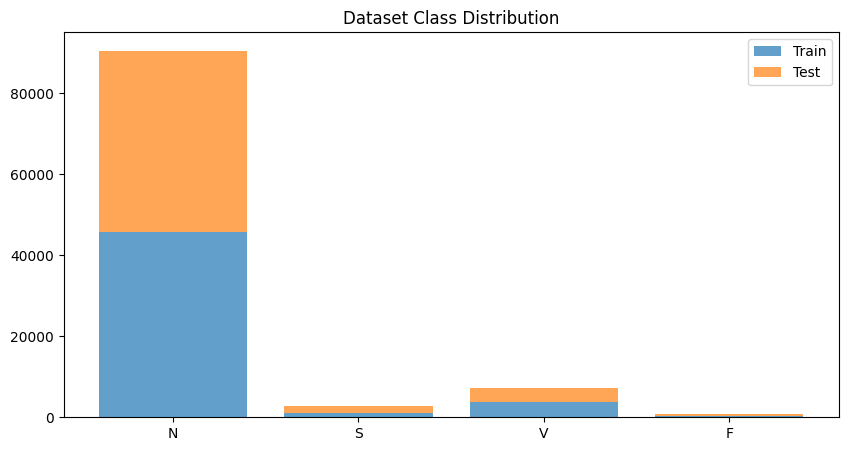

Train Counts: [45802   942  3786   414]


In [25]:
if HDF5_FILE.exists():
    with h5py.File(HDF5_FILE, 'r') as f:
        train_lbls = f['train']['labels'][:]
        test_lbls = f['test']['labels'][:]
    
    # Exclude Class 4 (Q) from analysis as we filter it out in Dataset
    valid_train = train_lbls[train_lbls != 4]
    valid_test = test_lbls[test_lbls != 4]
    
    names = ['N', 'S', 'V', 'F']
    counts_train = np.bincount(valid_train, minlength=4)[:4]
    counts_test = np.bincount(valid_test, minlength=4)[:4]
    
    plt.figure(figsize=(10, 5))
    plt.bar(names, counts_train, alpha=0.7, label='Train')
    plt.bar(names, counts_test, alpha=0.7, label='Test', bottom=counts_train)
    plt.title('Dataset Class Distribution')
    plt.legend()
    plt.show()
    print(f'Train Counts: {counts_train}')


## 3. Model Initialization & Pretraining Disclosure

### A. Pretrained Model
- **Model Name**: EfficientNet Bay (EfficientNet-B0)
- **Source**: `torchvision.models` (PyTorch)
- **Original Task**: ImageNet Classification (1000 generic object classes)

### B. Weight Usage
- **Used Pretrained Weights**: Yes (`weights=models.EfficientNet_B0_Weights.DEFAULT`)
- **Justification**: Transfer learning is essential here because clinical datasets are relatively small compared to ImageNet. Pretrained weights provide robust feature extractors (edges, textures) that accelerate convergence and improve accuracy.


## 4. Model Development

### Architecture Design
We adapt the standard EfficientNet-B0 for ECG Spectrograms:
1.  **Input Adaptation**: The first Convolutional layer is modified to accept **1-channel input** (Grayscale) instead of 3 (RGB). We initialize this layer by averaging the weights of the original RGB channels.
2.  **Backbone**: EfficientNet-B0 feature extractor.
3.  **Classifier Head**: The final Linear layer is replaced to output **4 logits** (corresponding to N, S, V, F).

### Training Strategy
- **Fine-Tuning**: **Full Fine-Tuning**. All layers are trainable. We do not freeze the backbone because spectrograms (medical imaging) differ significantly from natural images (dogs/cats), so valid adaptation of deep features is required.
- **Loss Function**: **Focal Loss** (Gamma=2.0). Chosen to handle the extreme class imbalance (N vs F ratio > 100:1) by penalizing easy classifications less.
- **Optimizer**: **Adam** (Learning Rate = 1e-4).
- **Batch Size**: 64.
- **Imbalance Handling**: **Weighted Random Sampling** is used in the DataLoader to oversample minority classes.


In [26]:
# --- Model Definition ---

class EfficientNetUltimate(nn.Module):
    def __init__(self, num_classes=4):
        super(EfficientNetUltimate, self).__init__()
        # 1. Load Pretrained Weights
        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.base = models.efficientnet_b0(weights=weights)
        
        # 2. Modify Input Layer (3 channels -> 1 channel)
        first_conv = self.base.features[0][0]
        # Sum weights across channel dim to keep intensity info
        original_weights = first_conv.weight.data.mean(dim=1, keepdim=True)
        self.base.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.base.features[0][0].weight.data = original_weights
        
        # 3. Modify Classifier (1000 classes -> 4 classes)
        num_ftrs = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
    def forward(self, x):
        return self.base(x)

# --- Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = (1-pt)**self.gamma * BCE_loss
        if self.reduction == 'mean': return torch.mean(F_loss)
        return F_loss

# --- Dataset Wrapper ---
class HDF5Dataset(Dataset):
    def __init__(self, h5_path, split):
        self.h5_path = h5_path
        self.split = split
        with h5py.File(h5_path, 'r') as f:
            all_lbls = f[split]['labels'][:]
        self.valid_idx = np.where(all_lbls != 4)[0] # Filter Q class
        self.length = len(self.valid_idx)
    def __len__(self): return self.length
    def __getitem__(self, idx):
        real_idx = self.valid_idx[idx]
        with h5py.File(self.h5_path, 'r') as f:
            img = f[self.split]['images'][real_idx]
            lbl = f[self.split]['labels'][real_idx]
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return img, torch.tensor(lbl, dtype=torch.long)


### Training Loop
The training procedure follows the standard Deep Learning paradigm:
1.  **Forward Pass**: Input images flow through the network to produce logits.
2.  **Loss Computation**: Focal Loss compares logits vs ground truth labels.
3.  **Backpropagation**: Gradients are calculated w.r.t parameters (`loss.backward()`).
4.  **Optimizer Step**: Parameters are updated (`optimizer.step()`).

**Validation Approach**: we use a fixed Train/Test split (inter-patient) defined by the MIT-BIH standard.


In [28]:
# --- Hyperparameters ---
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-4
MODEL_PATH = 'model/efficientnet_b0_detailed.pt'

# --- Data Loading ---
if HDF5_FILE.exists():
    train_ds = HDF5Dataset(HDF5_FILE, 'train')
    val_ds = HDF5Dataset(HDF5_FILE, 'test')
    
    # Weighted Sampler for Imbalance
    with h5py.File(HDF5_FILE, 'r') as f:
        train_all_lbls = f['train']['labels'][:]
    train_lbls = train_all_lbls[train_ds.valid_idx]
    class_counts = np.bincount(train_lbls)
    class_weights = 1. / (class_counts + 1e-6)
    sample_weights = class_weights[train_lbls]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Initialization
    model = EfficientNetUltimate(num_classes=4).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = FocalLoss(gamma=2)
    
    # --- 5. Outputs & Logs ---
    train_losses = []
    val_accuracies = []
    best_acc = 0.0
    
    print("Starting Training...")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
        
        for imgs, lbls in pbar:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            
            # 1. Forward Pass
            outputs = model(imgs)
            
            # 2. Loss Computation
            loss = criterion(outputs, lbls)
            
            # 3. Backpropagation
            optimizer.zero_grad()
            loss.backward()
            
            # 4. Optimizer Update
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'loss': running_loss / (pbar.n + 1)})
        
        train_losses.append(running_loss / len(train_loader))
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                outputs = model(imgs)
                _, pred = torch.max(outputs, 1)
                total += lbls.size(0)
                correct += (pred == lbls).sum().item()
        
        acc = 100 * correct / total
        val_accuracies.append(acc)
        print(f"Val Acc: {acc:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), MODEL_PATH)
            print("Saved Best Model")
else:
    print("HDF5 file missing. Please run the Data Prep cells above first.")


Starting Training...


Epoch 1/10:   0%|          | 0/796 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Training Curves
Visualizing the training process (Loss and Accuracy).


In [29]:
if 'train_losses' in locals() and len(train_losses) > 0:
    plt.figure(figsize=(12, 5))
    
    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Focal Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy', color='orange', marker='o')
    plt.title('Validation Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No training history found (model might not have trained).")


No training history found (model might not have trained).


## 6. Performance Metrics
We evaluate the model on the held-out Test Set using:
- **Confusion Matrix**: To visualize misclassifications.
- **Precision/Recall/F1-Score**: Per-class metrics.
- **Normalized Confusion Matrix**: To see class-wise accuracy.


Evaluating:   0%|          | 0/788 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           N      0.961     0.946     0.954     44706
           S      0.156     0.151     0.153      1837
           V      0.707     0.903     0.793      3446
           F      0.410     0.170     0.240       388

    accuracy                          0.908     50377
   macro avg      0.558     0.543     0.535     50377
weighted avg      0.910     0.908     0.908     50377



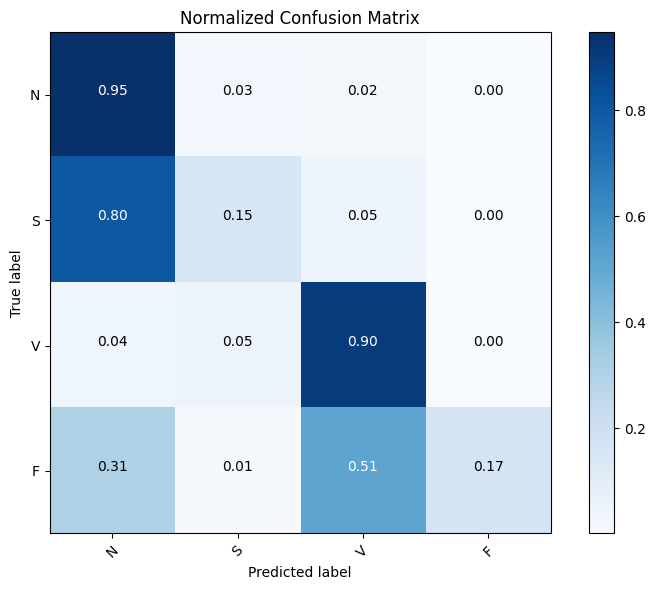

In [30]:
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
    
    all_preds, all_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(val_loader, desc='Evaluating'):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            _, pred = torch.max(outputs, 1)
            all_preds.extend(pred.cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
    
    target_names = ['N', 'S', 'V', 'F']
    print(classification_report(all_lbls, all_preds, target_names=target_names, digits=3))
    
    # Normalized Confusion Matrix
    cm = confusion_matrix(all_lbls, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Normalized Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=45)
    plt.yticks(tick_marks, target_names)
    
    thresh = cm_norm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", horizontalalignment="center", color="white" if cm_norm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
else:
    print("Model file not found.")
